# Part 1: Data Cleaning & Exploratory Data Analysis (EDA)


## 1. Load the Local Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load dataset directly from public URL
url = 'https://raw.githubusercontent.com/Vvijayaragupathy-uno/machinelearning/main/Titanic-Dataset.csv'
df = pd.read_csv(url)
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Data Cleaning

In [2]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values Before Cleaning:\n", missing_values[missing_values > 0])

Missing Values Before Cleaning:
 Age         177
Cabin       687
Embarked      2
dtype: int64


In [3]:
# 1. Handle Age: Fill with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Handle Embarked: Fill with mode (most frequent)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Check for Duplicates
duplicates_count = df.duplicated().sum()
print(f"\nDuplicates Found: {duplicates_count}")
if duplicates_count > 0:
    df = df.drop_duplicates()

# 4. Handle Outliers in Fare
fare_99th = df['Fare'].quantile(0.99)
df['Fare'] = np.where(df['Fare'] > fare_99th, fare_99th, df['Fare'])

# Verify no more missing values (except Cabin, which we will handle in Feature Engineering)
print("\nMissing Values After Cleaning:\n", df.isnull().sum()[df.isnull().sum() > 0])


Duplicates Found: 0

Missing Values After Cleaning:
 Cabin    687
dtype: int64


## 3. Exploratory Data Analysis (EDA)

### Visualization 1: Passenger Age Distribution (Histogram)

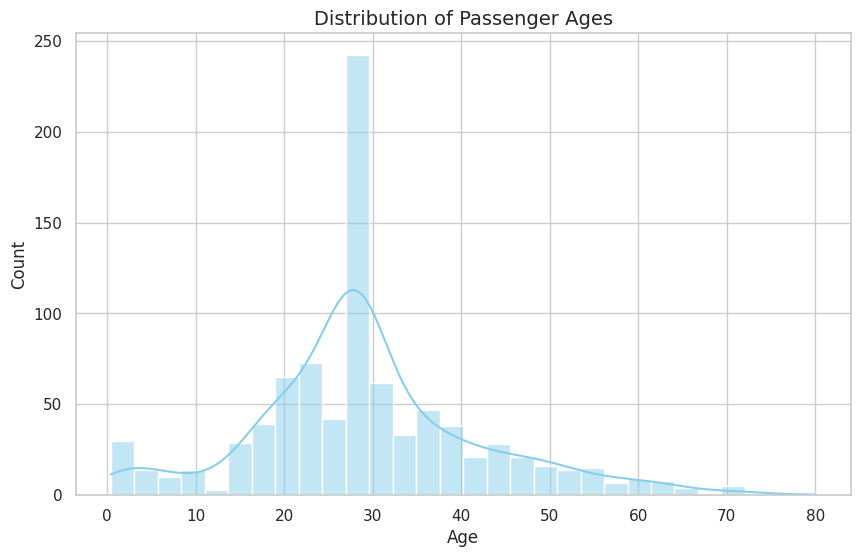

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Passenger Ages', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

### Visualization 2: Survival by Sex (Group Comparison / Countplot)

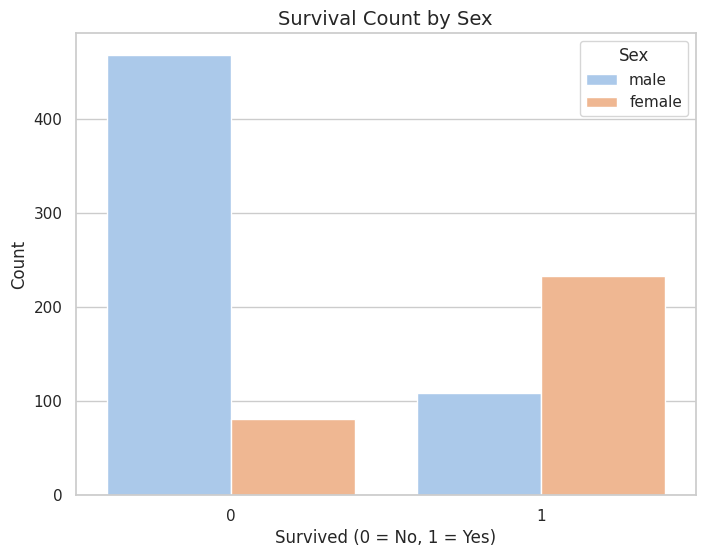

In [5]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Survived', hue='Sex', data=df, palette='pastel')
plt.title('Survival Count by Sex', fontsize=14)
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

### Visualization 3: Fare by Passenger Class (Boxplot / Outliers)

/tmp/ipykernel_20398/1625272998.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Fare', data=df, palette='Set2')


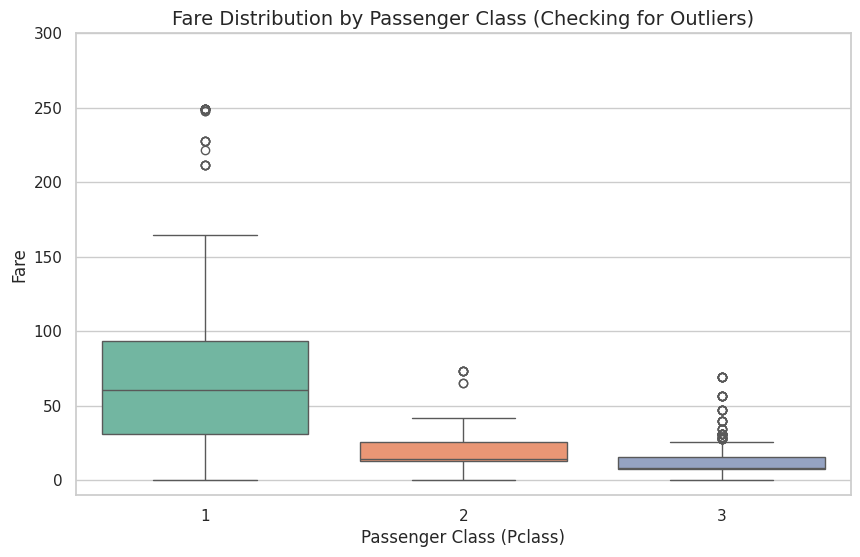

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Pclass', y='Fare', data=df, palette='Set2')
plt.title('Fare Distribution by Passenger Class (Checking for Outliers)', fontsize=14)
plt.xlabel('Passenger Class (Pclass)')
plt.ylabel('Fare')
# Zooming in a bit since some fares are extremely high
plt.ylim(-10, 300)
plt.show()

### Visualization 4: Correlation Heatmap of Numerical Features

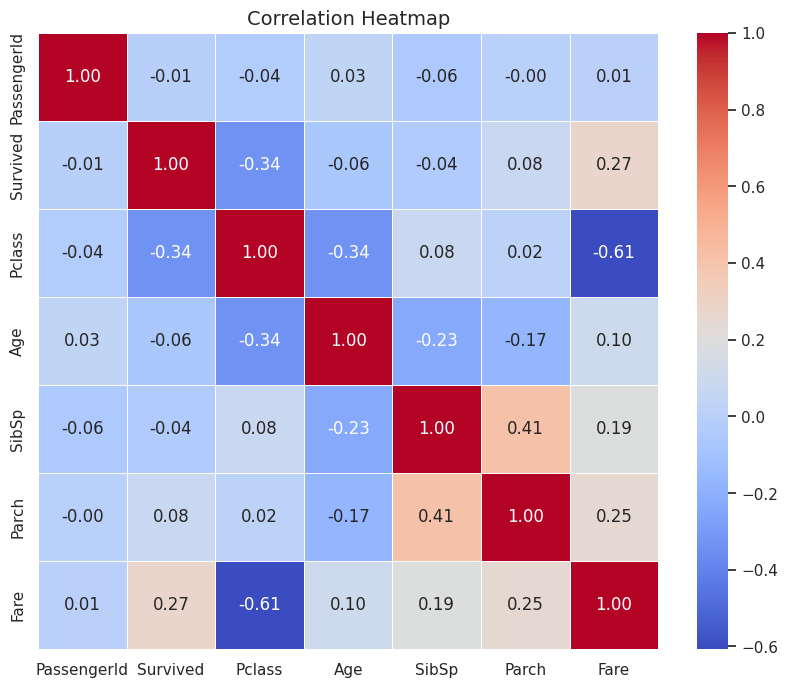

In [7]:
plt.figure(figsize=(10, 8))
# Select only numerical columns for correlation
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.show()

### Visualization 5: Survival by Passenger Class (Countplot)
This chart shows how socio-economic status (Ticket Class) affected a passenger's chances of survival.

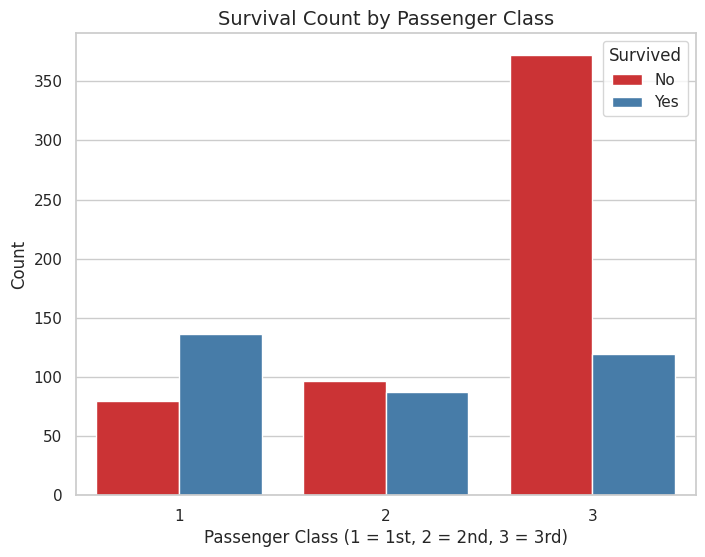

In [8]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='Set1')
plt.title('Survival Count by Passenger Class', fontsize=14)
plt.xlabel('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

## 4. Save Cleaned Data


In [10]:
from google.colab import drive

drive.mount('/content/drive')

# Save it directly into your Google Drive
import os
# Create the 'ml' folder if it doesn't exist yet
os.makedirs('/content/drive/MyDrive/ml', exist_ok=True)

df.to_csv('/content/drive/MyDrive/ml/titanic_cleaned.csv', index=False)
print("Saved directly to your Google Drive!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved directly to your Google Drive!
